Dataset shape: (191662, 14)
  cdc_case_earliest_dt cdc_report_dt pos_spec_dt             current_status  \
0           2021-08-11    2021-08-13         NaN  Laboratory-confirmed case   
1           2021-01-14    2021-02-02         NaN  Laboratory-confirmed case   
2           2022-01-25           NaN         NaN  Laboratory-confirmed case   
3           2022-01-30    2022-09-28         NaN  Laboratory-confirmed case   
4           2022-08-23    2022-08-23         NaN  Laboratory-confirmed case   

    sex      age_group race_ethnicity_combined  hosp_yn  icu_yn  death_yn  \
0  Male  10 - 19 Years         Hispanic/Latino        0      -1        -1   
1  Male  10 - 19 Years         Hispanic/Latino        0      -1         0   
2  Male  10 - 19 Years         Hispanic/Latino       -1      -1        -1   
3  Male  10 - 19 Years         Hispanic/Latino       -1      -1        -1   
4  Male  10 - 19 Years         Hispanic/Latino       -1      -1        -1   

   medcond_yn  year  month day_of_

,cdc_report_dt,cases,daily_change,rolling_avg_7
282,2020-12-22,675,518.0,238.857143
631,2021-12-06,3336,3231.0,614.571429
632,2021-12-07,149,-3187.0,587.857143
633,2021-12-08,160,11.0,592.857143
635,2021-12-10,151,-8.0,593.285714
636,2021-12-11,120,-31.0,597.142857
637,2021-12-12,73,-47.0,592.571429
647,2021-12-22,602,244.0,291.000000
648,2021-12-23,403,-199.0,313.857143
650,2021-12-25,137,-767.0,400.000000


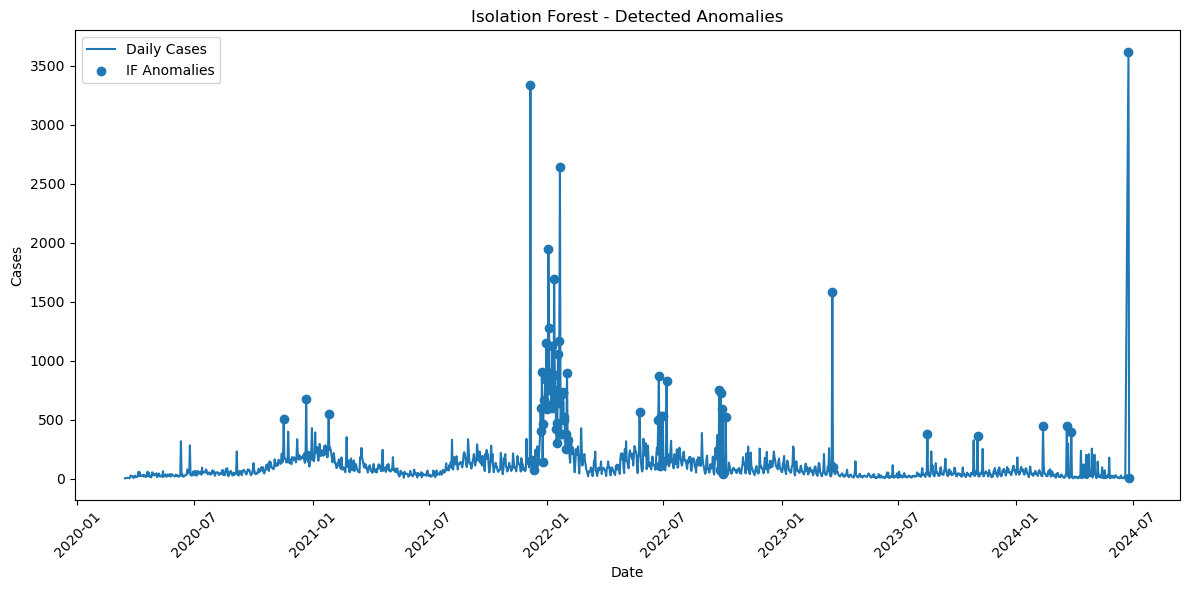

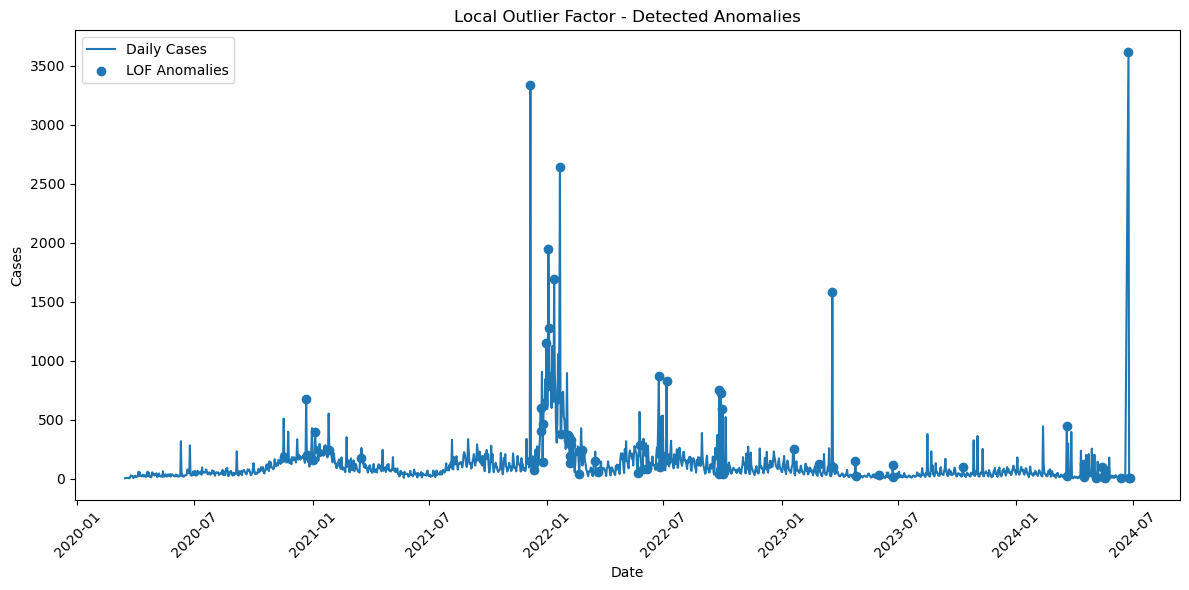

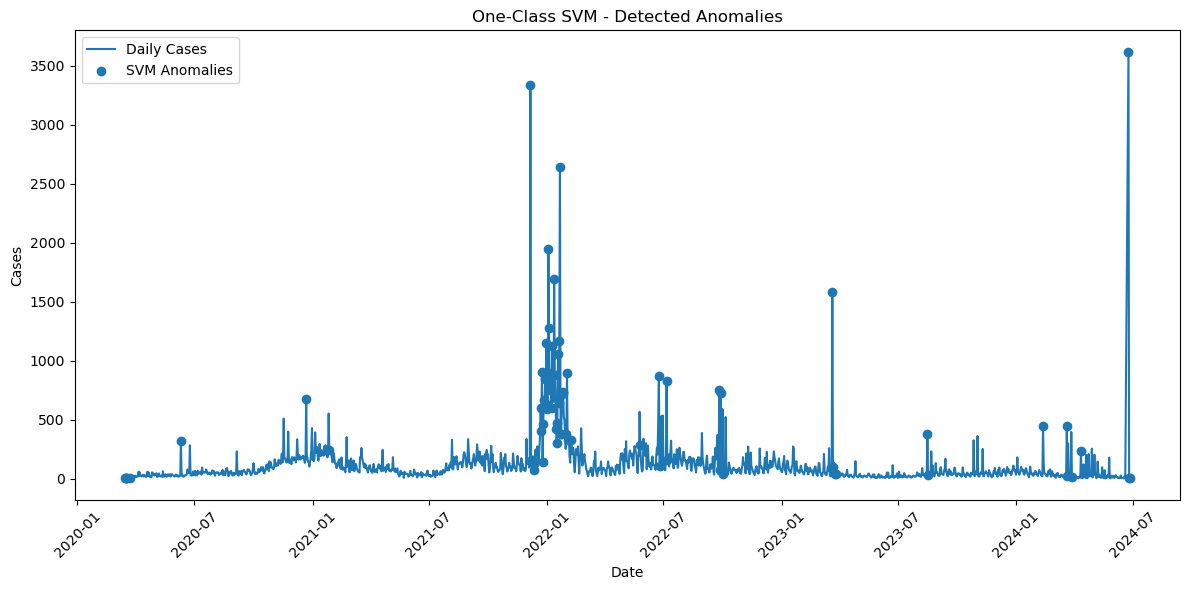

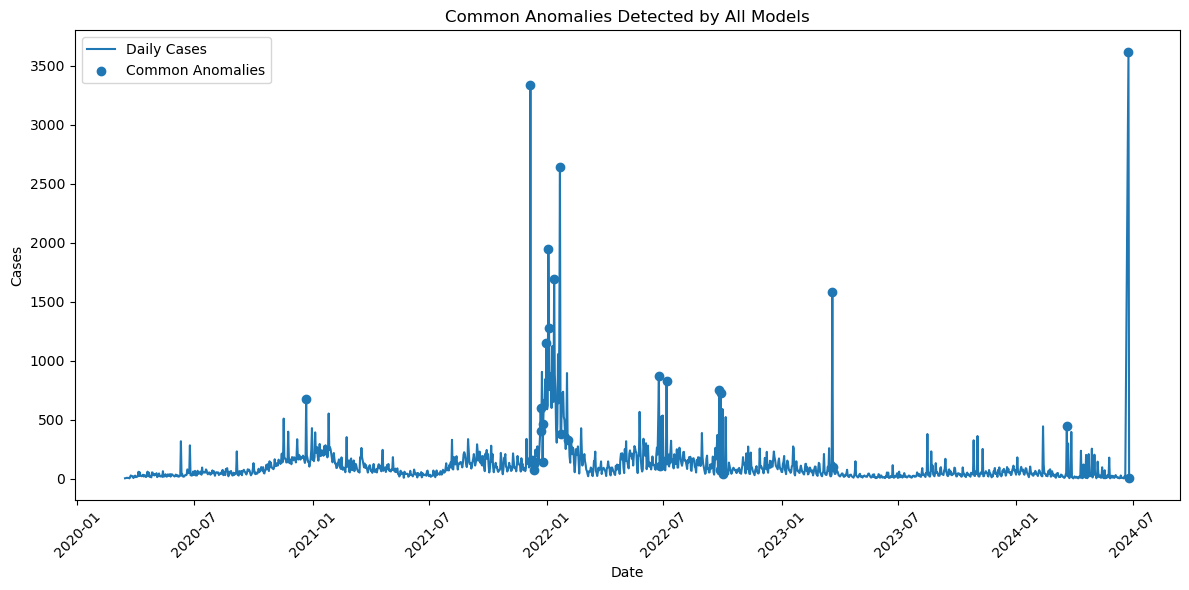


Final columns:
Index(['cdc_report_dt', 'cases', 'daily_change', 'rolling_avg_7', 'if_score',
       'if_anomaly', 'lof_anomaly', 'lof_score', 'svm_anomaly', 'svm_score',
       'common_anomaly'],
      dtype='object')

Sample results:
  cdc_report_dt  cases  daily_change  rolling_avg_7  if_score  if_anomaly  \
0    2020-03-15      2           1.0       1.285714  0.142021           1   
1    2020-03-16      3           1.0       1.571429  0.144726           1   
2    2020-03-17      5           2.0       2.142857  0.149881           1   
3    2020-03-18      6           1.0       2.714286  0.160123           1   
4    2020-03-19      5          -1.0       3.285714  0.155976           1   

   lof_anomaly  lof_score  svm_anomaly  svm_score  common_anomaly  
0            1  -1.236225           -1  -0.051599               0  
1            1  -1.227180           -1  -0.039942               0  
2            1  -1.169206           -1  -0.019484               0  
3            1  -1.150179    

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

# -------------------------
# 1. Load cleaned dataset
# -------------------------
file_path = r"C:\Users\ayush\Downloads\COVID-19 Data  project\0.5_sample_cleaned_dataset\0.5_sample_cleaned_dataset.xls"

# Some files are named .xls but are actually CSV-like.
# This tries CSV first, then Excel.
try:
    df = pd.read_csv(file_path, low_memory=False)
except Exception:
    df = pd.read_excel(file_path)

print("Dataset shape:", df.shape)
print(df.head())

# -------------------------
# 2. Convert date column
# -------------------------
df['cdc_report_dt'] = pd.to_datetime(df['cdc_report_dt'], errors='coerce')

# Keep only valid dates
df = df.dropna(subset=['cdc_report_dt']).copy()

# -------------------------
# 3. Create daily case counts
# -------------------------
daily_cases = (
    df.groupby('cdc_report_dt')
      .size()
      .reset_index(name='cases')
      .sort_values('cdc_report_dt')
      .reset_index(drop=True)
)

# -------------------------
# 4. Create features
# -------------------------
daily_cases['daily_change'] = daily_cases['cases'].diff()
daily_cases['rolling_avg_7'] = daily_cases['cases'].rolling(window=7).mean()

# Drop rows created as NaN by diff/rolling
daily_cases = daily_cases.dropna().reset_index(drop=True)

print("\nDaily cases preview:")
print(daily_cases.head())

# -------------------------
# 5. Prepare X for models
# -------------------------
feature_cols = ['cases', 'daily_change', 'rolling_avg_7']
X = daily_cases[feature_cols].copy()

# Scale features for LOF and One-Class SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 6. Isolation Forest
# -------------------------
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_model.fit(X_scaled)
daily_cases['if_score'] = iso_model.decision_function(X_scaled)
daily_cases['if_anomaly'] = iso_model.predict(X_scaled)   # -1 anomaly, 1 normal

# -------------------------
# 7. Local Outlier Factor
# -------------------------
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

daily_cases['lof_anomaly'] = lof_model.fit_predict(X_scaled)   # -1 anomaly, 1 normal
daily_cases['lof_score'] = lof_model.negative_outlier_factor_

# -------------------------
# 8. One-Class SVM
# -------------------------
svm_model = OneClassSVM(
    nu=0.05,
    kernel='rbf',
    gamma='scale'
)

svm_model.fit(X_scaled)
daily_cases['svm_anomaly'] = svm_model.predict(X_scaled)   # -1 anomaly, 1 normal
daily_cases['svm_score'] = svm_model.decision_function(X_scaled)

# -------------------------
# 9. Compare anomaly counts
# -------------------------
print("\nAnomaly counts")
print("Isolation Forest:", (daily_cases['if_anomaly'] == -1).sum())
print("LOF:", (daily_cases['lof_anomaly'] == -1).sum())
print("One-Class SVM:", (daily_cases['svm_anomaly'] == -1).sum())

# -------------------------
# 10. Find common anomalies
# -------------------------
daily_cases['common_anomaly'] = (
    (daily_cases['if_anomaly'] == -1) &
    (daily_cases['lof_anomaly'] == -1) &
    (daily_cases['svm_anomaly'] == -1)
).astype(int)

# -------------------------
# Extract anomalies
# -------------------------
anomalies_if = daily_cases[daily_cases['if_anomaly'] == -1]
anomalies_lof = daily_cases[daily_cases['lof_anomaly'] == -1]
anomalies_svm = daily_cases[daily_cases['svm_anomaly'] == -1]
common_anomalies = daily_cases[daily_cases['common_anomaly'] == 1]

# -------------------------
# Print results
# -------------------------
print("\nAnomaly counts")
print("Isolation Forest:", anomalies_if.shape[0])
print("LOF:", anomalies_lof.shape[0])
print("One-Class SVM:", anomalies_svm.shape[0])
print("Common anomalies detected by all 3 models:", common_anomalies.shape[0])

# -------------------------
# Export anomalies to CSV
# -------------------------
anomalies_if.to_csv("isolation_forest_anomalies.csv", index=False)
anomalies_lof.to_csv("lof_anomalies.csv", index=False)
anomalies_svm.to_csv("svm_anomalies.csv", index=False)
common_anomalies.to_csv("common_anomalies.csv", index=False)

print("CSV files exported successfully!")

# -------------------------
# Display table
# -------------------------
from IPython.display import display

print("\nTop 32 Common Anomalies:")
display(common_anomalies[['cdc_report_dt', 'cases', 'daily_change', 'rolling_avg_7']].head(32))

# -------------------------
# 11. Plot: Isolation Forest
# -------------------------
plt.figure(figsize=(12, 6))
plt.plot(daily_cases['cdc_report_dt'], daily_cases['cases'], label='Daily Cases')
iso_anoms = daily_cases[daily_cases['if_anomaly'] == -1]
plt.scatter(iso_anoms['cdc_report_dt'], iso_anoms['cases'], label='IF Anomalies')
plt.title("Isolation Forest - Detected Anomalies")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------
# 12. Plot: LOF
# -------------------------
plt.figure(figsize=(12, 6))
plt.plot(daily_cases['cdc_report_dt'], daily_cases['cases'], label='Daily Cases')
lof_anoms = daily_cases[daily_cases['lof_anomaly'] == -1]
plt.scatter(lof_anoms['cdc_report_dt'], lof_anoms['cases'], label='LOF Anomalies')
plt.title("Local Outlier Factor - Detected Anomalies")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------
# 13. Plot: One-Class SVM
# -------------------------
plt.figure(figsize=(12, 6))
plt.plot(daily_cases['cdc_report_dt'], daily_cases['cases'], label='Daily Cases')
svm_anoms = daily_cases[daily_cases['svm_anomaly'] == -1]
plt.scatter(svm_anoms['cdc_report_dt'], svm_anoms['cases'], label='SVM Anomalies')
plt.title("One-Class SVM - Detected Anomalies")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------
# 14. Plot: Common anomalies
# -------------------------
plt.figure(figsize=(12, 6))
plt.plot(daily_cases['cdc_report_dt'], daily_cases['cases'], label='Daily Cases')
common_anoms = daily_cases[daily_cases['common_anomaly'] == 1]
plt.scatter(common_anoms['cdc_report_dt'], common_anoms['cases'], label='Common Anomalies')
plt.title("Common Anomalies Detected by All Models")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------
# 15. View final output
# -------------------------
print("\nFinal columns:")
print(daily_cases.columns)

print("\nSample results:")
print(daily_cases.head())

# Anomaly Detection Modeling

## 1. Feature Preparation
To perform anomaly detection, the dataset was transformed into a time-series format by aggregating case-level data into daily counts using the reporting date (cdc_report_dt).

Additional features were created to capture temporal patterns and trends in the data:

- cases: Daily number of reported COVID-19 cases  
- daily_change: Difference in case counts between consecutive days  
- rolling_avg_7: 7-day rolling average of daily cases  

These features capture both short-term fluctuations and long-term trends, making them suitable for anomaly detection models.

To ensure clean input data, missing values generated during feature creation (due to differencing and rolling operations) were removed.

---

## 2. Isolation Forest
The Isolation Forest algorithm was implemented as the primary anomaly detection model. This algorithm isolates observations by randomly partitioning data and is effective in detecting global anomalies.

The model produced:

- Anomaly scores indicating how abnormal each observation is  
- Binary labels, where:  
  - **-1 → anomaly**  
  - **1 → normal observation**  

Isolation Forest was chosen due to its efficiency and strong performance.

---

## 3. Local Outlier Factor (LOF)
The Local Outlier Factor (LOF) model detects anomalies based on local density differences.

- Points with lower density than their neighbors are marked as anomalies  

Output:
- **-1 → anomaly**  
- **1 → normal**  

LOF is useful for detecting local anomalies that global models may miss.

---

## 4. One-Class SVM
The One-Class Support Vector Machine (SVM) model was used to learn the boundary of normal data points.

- Points inside boundary → normal  
- Points outside boundary → anomalies  

This model is effective for capturing complex, non-linear patterns in the data.

---

## 5. Model Comparison
The results of all three models were compared:

- Isolation Forest detected **78 anomalies**  
- LOF detected **78 anomalies**  
- One-Class SVM detected **77 anomalies**  
- **32 anomalies were common across all three models**

Isolation Forest performed well in identifying major spikes, while LOF captured local variations. One-Class SVM showed sensitivity to scaling but still identified meaningful anomalies.

The overlapping anomalies represent the most reliable irregularities in the dataset.

---

## 6. Visualization of Anomalies
Time-series plots were created to visualize anomalies detected by each model. Anomalous points were highlighted on the daily case curve.

The visualizations revealed:

- Sudden spikes in case counts  
- Sharp drops following spikes  
- Clear deviations from overall trends  

These anomalies align with real-world COVID-19 patterns and reporting irregularities.

---

## 7. Interpretation of Common Anomalies

The table above presents the **32 common anomalies** detected consistently by all three models (Isolation Forest, LOF, and One-Class SVM). These points represent the most reliable anomalies in the dataset.

A closer examination of the table reveals several important patterns:

- **Large positive spikes in cases**  
  For example, on **2021-12-06**, the number of cases suddenly increased to **3336**, with a very high daily change of **+3231**, significantly exceeding the rolling average. This indicates a sudden surge in reported cases.

- **Sharp negative drops following spikes**  
  Immediately after the spike, on **2021-12-07**, cases dropped drastically to **149**, resulting in a large negative change (**-3187**). Such sudden drops are unlikely to reflect real-world infection dynamics and instead suggest reporting corrections or delays.

- **High deviation from rolling averages**  
  Many anomalous points show significant differences between actual cases and the 7-day rolling average. This indicates abnormal deviations from the expected trend.

- **Clustered anomalies during peak periods**  
  Several anomalies occur around late 2021 and early 2022, which corresponds to major COVID-19 waves (e.g., Omicron surge). This suggests that anomalies are associated with real-world outbreak events.

### Possible Causes of Anomalies

The detected anomalies are likely due to:

- Sudden outbreak surges  
- Reporting delays or batch updates  
- Data corrections or backlog adjustments  

### Conclusion

Since all three models identified these same data points as anomalies, they are highly reliable and not due to random noise. These anomalies represent meaningful irregularities in the dataset and provide valuable insights into unusual patterns in COVID-19 reporting.

---

## 8. Comparison of Model-Specific and Overlapping Anomalies

While all three models detected a similar number of anomalies, they do not always identify the same data points. This difference highlights how each model captures anomalies from a different perspective.

### Model-Specific Anomalies

Each model identified some anomalies that were not detected by the others:

- **Isolation Forest** tends to identify **global anomalies**, such as large spikes in case counts that stand out across the entire dataset.  
- **Local Outlier Factor (LOF)** focuses on **local density**, detecting points that are unusual compared to their immediate neighbors, even if they are not extreme globally.  
- **One-Class SVM** identifies anomalies based on a learned boundary of normal behavior and is sensitive to **complex and non-linear patterns**.  

As a result, some anomalies are unique to each model because they represent different types of irregularities.

### Overlapping vs Non-Overlapping Anomalies

The anomalies can be categorized into three groups:

- **Single-model anomalies** → detected by only one model (less reliable)  
- **Partial overlap anomalies** → detected by two models (moderately reliable)  
- **Common anomalies (32 points)** → detected by all three models (most reliable)  

The **32 overlapping anomalies** are the most important because:

- All models independently agree on them  
- They represent strong and consistent deviations  
- They are unlikely to be caused by noise or model bias  

### Why This Strengthens the Analysis

Using multiple models improves the robustness of anomaly detection:

- It reduces false positives from individual models  
- It captures different types of anomalies (global, local, and boundary-based)  
- It allows cross-validation of results through agreement  

The overlap between models provides strong evidence that the detected anomalies are meaningful and significant.

### Final Insight

The combination of multiple anomaly detection techniques ensures a more comprehensive understanding of irregular patterns in the data. While individual models highlight different aspects of anomalies, the overlapping results provide the most trustworthy insights for further analysis.

---

## 9. Key Insights

- The dataset exhibits strong temporal patterns with multiple peaks  
- Anomaly detection models successfully identified unusual spikes and drops  
- Isolation Forest provided stable and interpretable results  
- Combining multiple models improves reliability  
- Common anomalies are highly meaningful and consistent  

---

## Summary

Multiple anomaly detection models were implemented, including Isolation Forest, Local Outlier Factor, and One-Class SVM. These models were trained on time-series features and successfully identified anomalies in daily COVID-19 case counts.

The agreement across models confirms that the detected anomalies are not random noise but represent real irregularities in reporting patterns.

These findings demonstrate the effectiveness of unsupervised learning techniques in detecting unusual behavior in large-scale public health data.